# Notebook 12 - Gaussian Mixture Clustering
## Airbnb Capstone | Probabilistic market segmentation

### Structure
1. Setup and paths
2. Feature selection
3. Load Madrid and Tokyo model-ready datasets
4. Prepare numeric clustering matrices
5. Scale features and explain Gaussian distance
6. Evaluate number of components with AIC, BIC and silhouette
7. Fit a four-component Gaussian Mixture Model
8. Profile and name the groups
9. Inspect membership confidence
10. PCA visualisation
11. Save outputs
12. Key metrics and interpretation

---
## 1. Setup and Paths

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42

This cell imports the libraries needed for Gaussian Mixture clustering. The most important addition is `GaussianMixture` from scikit-learn.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "1. Data").exists() and (candidate / "2. Code").exists():
            return candidate
    raise FileNotFoundError("Could not find the CAPSTONE project root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "1. Data"
MODEL_READY_DIR = DATA_DIR / "model_ready"
ML_OUTPUT_DIR = DATA_DIR / "Outputs" / "ml_models"
CLUSTER_OUTPUT_DIR = ML_OUTPUT_DIR / "clustering"
CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Model-ready folder:", MODEL_READY_DIR)
print("Clustering output folder:", CLUSTER_OUTPUT_DIR)

Project root: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE
Model-ready folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\model_ready
Clustering output folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering


This function finds the CAPSTONE folder automatically. It keeps the notebook portable as long as the `1. Data` and `2. Code` folders keep the same structure.

---
## 2. Feature Selection

In [3]:
CITY_FILES = {
    "Madrid": MODEL_READY_DIR / "madrid_model_ready.csv",
    "Tokyo": MODEL_READY_DIR / "tokyo_model_ready.csv",
}

CLUSTER_FEATURES = [
    "price_eur",
    "accommodates",
    "bedrooms",
    "amenities_count",
    "distance_to_center_km",
    "availability_365",
    "review_scores_rating",
    "host_is_superhost",
    "minimum_nights_capped",
]

FEATURE_REASONING = pd.DataFrame(
    [
        ["price_eur", "Market position", "Separates cheaper, mid-market and premium listings."],
        ["accommodates", "Capacity", "Captures guest capacity."],
        ["bedrooms", "Capacity", "Captures the physical size of the listing."],
        ["amenities_count", "Comfort", "Approximates how feature-rich the stay is."],
        ["distance_to_center_km", "Location", "Centrality proxy from the EDA."],
        ["availability_365", "Supply", "Distinguishes restricted or high-demand listings from widely available ones."],
        ["review_scores_rating", "Quality", "Adds the guest satisfaction signal."],
        ["host_is_superhost", "Host", "Adds a simple host-quality indicator."],
        ["minimum_nights_capped", "Booking rule", "Captures short-stay versus longer-stay behaviour."],
    ],
    columns=["attribute", "theme", "why used"],
)

N_COMPONENTS = 4
SEGMENT_LABELS = ["Value", "Standard", "Premium", "Luxury"]
COVARIANCE_TYPE = "full"

print("Gaussian Mixture features used:")
display(FEATURE_REASONING)

Gaussian Mixture features used:


,attribute,theme,why used
0,price_eur,Market position,"Separates cheaper, mid-market and premium list..."
1,accommodates,Capacity,Captures guest capacity.
2,bedrooms,Capacity,Captures the physical size of the listing.
3,amenities_count,Comfort,Approximates how feature-rich the stay is.
4,distance_to_center_km,Location,Centrality proxy from the EDA.
5,availability_365,Supply,Distinguishes restricted or high-demand listin...
6,review_scores_rating,Quality,Adds the guest satisfaction signal.
7,host_is_superhost,Host,Adds a simple host-quality indicator.
8,minimum_nights_capped,Booking rule,Captures short-stay versus longer-stay behaviour.


We reuse the same nine attributes as the K-means notebook. This makes the two algorithms comparable because any difference comes mainly from the clustering method, not from a different feature set.

---
## 3. Load the Model-ready Datasets

In [4]:
def load_city_datasets(city_files: dict[str, Path]) -> dict[str, pd.DataFrame]:
    datasets = {}
    for city, path in city_files.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing model-ready data for {city}: {path}")
        datasets[city] = pd.read_csv(path)
    return datasets


datasets = load_city_datasets(CITY_FILES)

for city, df in datasets.items():
    print(f"{city}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

Madrid: 17,770 rows, 87 columns
Tokyo: 23,765 rows, 86 columns


This loads the Madrid and Tokyo model-ready CSV files. We use model-ready data because the attributes are already cleaned and aligned for modelling.

In [5]:
def check_feature_availability(datasets: dict[str, pd.DataFrame], features: list[str]) -> pd.DataFrame:
    rows = []
    for city, df in datasets.items():
        for feature in features:
            rows.append(
                {
                    "city": city,
                    "feature": feature,
                    "available": feature in df.columns,
                    "missing_values": int(df[feature].isna().sum()) if feature in df.columns else None,
                    "missing_pct": round(df[feature].isna().mean() * 100, 2) if feature in df.columns else None,
                }
            )
    return pd.DataFrame(rows)


feature_check = check_feature_availability(datasets, CLUSTER_FEATURES)
display(feature_check)

,city,feature,available,missing_values,missing_pct
0,Madrid,price_eur,True,0,0.00
1,Madrid,accommodates,True,0,0.00
2,Madrid,bedrooms,True,30,0.17
3,Madrid,amenities_count,True,0,0.00
4,Madrid,distance_to_center_km,True,0,0.00
5,Madrid,availability_365,True,0,0.00
6,Madrid,review_scores_rating,True,2825,15.90
7,Madrid,host_is_superhost,True,515,2.90
8,Madrid,minimum_nights_capped,True,0,0.00
9,Tokyo,price_eur,True,0,0.00


This check confirms that the selected attributes exist and shows how much missingness each feature has. Rows with missing clustering inputs are removed before fitting.

---
## 4. Prepare Numeric Clustering Matrices

In [6]:
def prepare_clustering_frame(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    missing = sorted(set(features) - set(df.columns))
    if missing:
        raise ValueError(f"Missing clustering features: {missing}")

    working = df[features].replace([np.inf, -np.inf], np.nan).copy()
    working = working.dropna().copy()
    working.insert(0, "model_ready_row", working.index)
    return working


working_frames = {}
for city, df in datasets.items():
    working_frames[city] = prepare_clustering_frame(df, CLUSTER_FEATURES)
    removed = len(df) - len(working_frames[city])
    print(f"{city}: {len(working_frames[city]):,} rows kept, {removed:,} rows removed because of missing clustering values")

Madrid: 14,446 rows kept, 3,324 rows removed because of missing clustering values
Tokyo: 19,158 rows kept, 4,607 rows removed because of missing clustering values


Gaussian Mixture Models cannot fit rows with missing values, so this cell keeps complete rows for the nine clustering attributes. The `model_ready_row` column is kept for traceability.

In [7]:
def describe_clustering_inputs(working_frames: dict[str, pd.DataFrame], features: list[str]) -> pd.DataFrame:
    summaries = []
    for city, frame in working_frames.items():
        summary = frame[features].describe().T.reset_index().rename(columns={"index": "feature"})
        summary.insert(0, "city", city)
        summaries.append(summary)
    return pd.concat(summaries, ignore_index=True)


input_summary = describe_clustering_inputs(working_frames, CLUSTER_FEATURES)
display(input_summary.round(2))

,city,feature,count,mean,std,min,25%,50%,75%,max
0,Madrid,price_eur,14446.0,115.68,61.35,8.00,70.00,106.00,150.00,305.00
1,Madrid,accommodates,14446.0,3.19,1.68,1.00,2.00,3.00,4.00,16.00
2,Madrid,bedrooms,14446.0,1.29,0.82,0.00,1.00,1.00,2.00,25.00
3,Madrid,amenities_count,14446.0,28.72,12.43,0.00,21.00,29.00,37.00,89.00
4,Madrid,distance_to_center_km,14446.0,2.71,2.48,0.01,0.78,1.85,4.04,13.49
5,Madrid,availability_365,14446.0,204.10,115.79,0.00,88.00,232.00,312.00,365.00
6,Madrid,review_scores_rating,14446.0,4.63,0.48,1.00,4.53,4.75,4.90,5.00
7,Madrid,host_is_superhost,14446.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
8,Madrid,minimum_nights_capped,14446.0,5.51,9.04,1.00,1.00,2.00,3.00,30.00
9,Tokyo,price_eur,19158.0,110.23,56.39,9.30,67.80,96.37,140.52,283.98


This summary shows the feature scales before standardisation. Price, availability, distance and ratings all live on different scales, so scaling is required.

---
## 5. Scale Features and Explain Gaussian Distance

In [8]:
def scale_city_features(working: pd.DataFrame, features: list[str]) -> tuple[np.ndarray, StandardScaler]:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(working[features])
    return X_scaled, scaler


scaled_data = {}
scalers = {}
for city, working in working_frames.items():
    X_scaled, scaler = scale_city_features(working, CLUSTER_FEATURES)
    scaled_data[city] = X_scaled
    scalers[city] = scaler
    print(f"{city}: scaled matrix shape = {X_scaled.shape}")

Madrid: scaled matrix shape = (14446, 9)
Tokyo: scaled matrix shape = (19158, 9)


Gaussian Mixture Models estimate several Gaussian distributions and assign each listing to the component where it has the highest probability. With `covariance_type='full'`, each component can have its own shape and orientation. This is more flexible than K-means.

Unlike K-means, GMM is not simply assigning to the nearest centroid by Euclidean distance. It uses Gaussian likelihoods, which are covariance-aware and are closely related to Mahalanobis-style distance within each component. We still standardize the inputs so no single unit dominates the model.

---
## 6. Evaluate Number of Components

In [9]:
def calculate_gmm_diagnostics(
    X_scaled: np.ndarray,
    city: str,
    component_values=range(2, 9),
    covariance_type: str = COVARIANCE_TYPE,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rows = []
    for n_components in component_values:
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            random_state=random_state,
            n_init=5,
            reg_covar=1e-6,
        )
        labels = model.fit_predict(X_scaled)
        probabilities = model.predict_proba(X_scaled)
        max_probability = probabilities.max(axis=1)

        rows.append(
            {
                "city": city,
                "n_components": n_components,
                "aic": model.aic(X_scaled),
                "bic": model.bic(X_scaled),
                "silhouette_score": silhouette_score(
                    X_scaled,
                    labels,
                    sample_size=min(5000, len(X_scaled)),
                    random_state=random_state,
                ),
                "avg_max_membership_probability": float(max_probability.mean()),
                "low_confidence_share": float((max_probability < 0.60).mean()),
                "rows_used": len(X_scaled),
                "covariance_type": covariance_type,
            }
        )
    return pd.DataFrame(rows)


diagnostic_frames = []
for city, X_scaled in scaled_data.items():
    diagnostic_frames.append(calculate_gmm_diagnostics(X_scaled, city))

scores_df = pd.concat(diagnostic_frames, ignore_index=True)
display(scores_df.style.format({
    "aic": "{:.2f}",
    "bic": "{:.2f}",
    "silhouette_score": "{:.4f}",
    "avg_max_membership_probability": "{:.3f}",
    "low_confidence_share": "{:.2%}",
}))

,city,n_components,aic,bic,silhouette_score,avg_max_membership_probability,low_confidence_share,rows_used,covariance_type
0,Madrid,2,222798.57,223624.59,0.0989,0.998,0.08%,14446,full
1,Madrid,3,111001.80,112244.62,0.1092,1.000,0.00%,14446,full
2,Madrid,4,55726.36,57385.98,0.1210,0.997,0.08%,14446,full
3,Madrid,5,42878.02,44954.44,0.1170,0.995,0.24%,14446,full
4,Madrid,6,31645.51,34138.73,0.1170,0.988,0.59%,14446,full
5,Madrid,7,44734.92,47644.94,0.0559,0.979,1.23%,14446,full
6,Madrid,8,-13863.76,-10536.94,0.1074,0.990,0.48%,14446,full
7,Tokyo,2,373584.25,374441.04,0.3142,0.991,0.33%,19158,full
8,Tokyo,3,175849.38,177138.50,0.1736,0.998,0.10%,19158,full
9,Tokyo,4,109102.02,110823.47,0.1968,0.998,0.13%,19158,full


This function tries different numbers of Gaussian components. The important diagnostics are:

- **AIC:** lower is better; rewards fit but penalises complexity.
- **BIC:** lower is better; penalises complexity more strongly than AIC.
- **Silhouette score:** higher is better; measures separation after assigning each row to its most likely component.
- **Average max membership probability:** higher means listings are assigned more confidently.
- **Low confidence share:** share of listings where the best component probability is below 60%.

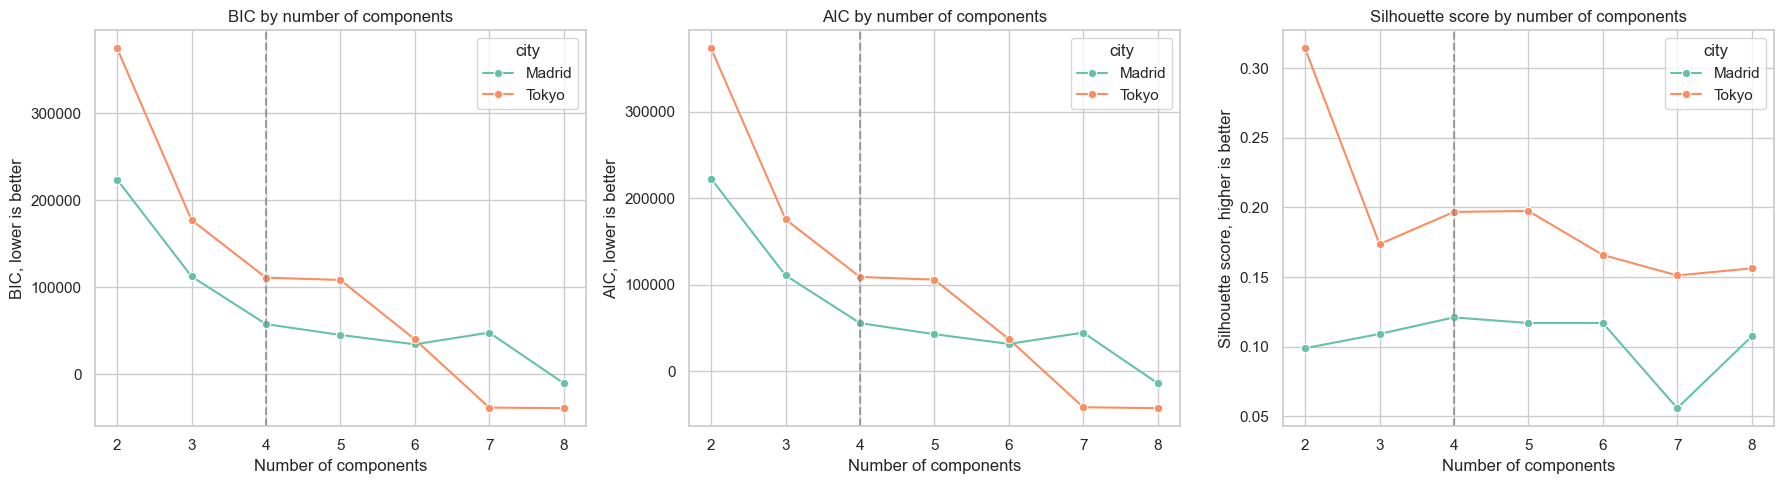

In [10]:
def plot_gmm_diagnostics(scores: pd.DataFrame, selected_components: int = N_COMPONENTS) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.lineplot(data=scores, x="n_components", y="bic", hue="city", marker="o", ax=axes[0])
    axes[0].axvline(selected_components, color="grey", linestyle="--", alpha=0.7)
    axes[0].set_title("BIC by number of components")
    axes[0].set_xlabel("Number of components")
    axes[0].set_ylabel("BIC, lower is better")

    sns.lineplot(data=scores, x="n_components", y="aic", hue="city", marker="o", ax=axes[1])
    axes[1].axvline(selected_components, color="grey", linestyle="--", alpha=0.7)
    axes[1].set_title("AIC by number of components")
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("AIC, lower is better")

    sns.lineplot(data=scores, x="n_components", y="silhouette_score", hue="city", marker="o", ax=axes[2])
    axes[2].axvline(selected_components, color="grey", linestyle="--", alpha=0.7)
    axes[2].set_title("Silhouette score by number of components")
    axes[2].set_xlabel("Number of components")
    axes[2].set_ylabel("Silhouette score, higher is better")

    plt.tight_layout()
    plt.show()


plot_gmm_diagnostics(scores_df)

These plots help compare model fit and interpretability. AIC/BIC can prefer more components, while the project may still choose four components to keep the business labels easy to explain.

---
## 7. Fit a Four-component Gaussian Mixture Model

In [11]:
def fit_gmm_segments(
    working: pd.DataFrame,
    X_scaled: np.ndarray,
    n_components: int = N_COMPONENTS,
    covariance_type: str = COVARIANCE_TYPE,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, GaussianMixture]:
    model = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=random_state,
        n_init=10,
        reg_covar=1e-6,
    )
    component_id = model.fit_predict(X_scaled)
    probabilities = model.predict_proba(X_scaled)

    segmented = working.copy()
    segmented["component_id"] = component_id
    segmented["membership_probability"] = probabilities.max(axis=1)
    segmented["low_confidence_assignment"] = segmented["membership_probability"] < 0.60
    return segmented, model


segmented_frames = {}
gmm_models = {}
for city in working_frames:
    segmented, model = fit_gmm_segments(working_frames[city], scaled_data[city])
    segmented_frames[city] = segmented
    gmm_models[city] = model
    print(f"{city}: fitted GMM with {model.n_components} components and {model.covariance_type} covariance")

Madrid: fitted GMM with 4 components and full covariance
Tokyo: fitted GMM with 4 components and full covariance


This fits the final four-component GMM separately for Madrid and Tokyo. Each listing gets a component ID and a membership probability. The probability is useful because it tells us how confident the model is about that listing's segment.

---
## 8. Profile and Name the Groups

In [12]:
def profile_gmm_segments(segmented: pd.DataFrame, city: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    profile = (
        segmented
        .groupby("component_id")
        .agg(
            listings=("price_eur", "size"),
            median_price_eur=("price_eur", "median"),
            mean_price_eur=("price_eur", "mean"),
            median_accommodates=("accommodates", "median"),
            median_bedrooms=("bedrooms", "median"),
            median_amenities=("amenities_count", "median"),
            median_distance_to_center_km=("distance_to_center_km", "median"),
            median_availability_365=("availability_365", "median"),
            mean_review_score=("review_scores_rating", "mean"),
            superhost_rate=("host_is_superhost", "mean"),
            median_minimum_nights=("minimum_nights_capped", "median"),
            avg_membership_probability=("membership_probability", "mean"),
            low_confidence_share=("low_confidence_assignment", "mean"),
        )
        .reset_index()
        .sort_values("median_price_eur")
        .reset_index(drop=True)
    )

    profile["segment"] = SEGMENT_LABELS[:len(profile)]
    profile["city"] = city

    component_to_segment = dict(zip(profile["component_id"], profile["segment"]))
    labelled = segmented.copy()
    labelled["segment"] = labelled["component_id"].map(component_to_segment)
    labelled["city"] = city

    ordered_columns = [
        "city", "segment", "component_id", "listings", "median_price_eur", "mean_price_eur",
        "median_accommodates", "median_bedrooms", "median_amenities",
        "median_distance_to_center_km", "median_availability_365",
        "mean_review_score", "superhost_rate", "median_minimum_nights",
        "avg_membership_probability", "low_confidence_share",
    ]
    profile = profile[ordered_columns]
    numeric_cols = profile.select_dtypes(include="number").columns
    profile[numeric_cols] = profile[numeric_cols].round(3)

    return profile, labelled


profile_frames = []
labelled_frames = []
for city, segmented in segmented_frames.items():
    profile, labelled = profile_gmm_segments(segmented, city)
    profile_frames.append(profile)
    labelled_frames.append(labelled[["city", "model_ready_row", "component_id", "segment", "membership_probability", "low_confidence_assignment", *CLUSTER_FEATURES]])

profiles_df = pd.concat(profile_frames, ignore_index=True)
segments_df = pd.concat(labelled_frames, ignore_index=True)

display(profiles_df.style.format({
    "median_price_eur": "{:.2f}",
    "mean_price_eur": "{:.2f}",
    "median_accommodates": "{:.1f}",
    "median_bedrooms": "{:.1f}",
    "median_amenities": "{:.1f}",
    "median_distance_to_center_km": "{:.2f}",
    "median_availability_365": "{:.0f}",
    "mean_review_score": "{:.2f}",
    "superhost_rate": "{:.2%}",
    "median_minimum_nights": "{:.0f}",
    "avg_membership_probability": "{:.3f}",
    "low_confidence_share": "{:.2%}",
}))

,city,segment,component_id,listings,median_price_eur,mean_price_eur,median_accommodates,median_bedrooms,median_amenities,median_distance_to_center_km,median_availability_365,mean_review_score,superhost_rate,median_minimum_nights,avg_membership_probability,low_confidence_share
0,Madrid,Value,2,208,92.50,103.81,3.0,1.0,20.0,2.47,292,2.46,23.60%,3,0.974,1.90%
1,Madrid,Standard,0,5511,94.00,98.10,2.0,1.0,26.0,1.84,246,4.58,0.00%,1,0.996,0.10%
2,Madrid,Premium,1,4305,108.00,117.70,3.0,1.0,34.0,1.75,186,4.85,100.00%,2,1.000,0.00%
3,Madrid,Luxury,3,4422,129.00,136.18,4.0,2.0,28.0,1.88,247,4.58,0.00%,3,0.998,0.10%
4,Tokyo,Value,3,1252,66.96,79.67,3.0,1.0,30.0,6.44,157,4.67,22.00%,30,0.998,0.00%
5,Tokyo,Standard,2,602,73.60,90.08,3.0,1.0,31.0,12.46,201,4.38,55.50%,2,0.970,2.70%
6,Tokyo,Premium,1,8956,90.31,104.42,3.0,1.0,30.0,6.58,151,4.65,0.00%,1,0.999,0.10%
7,Tokyo,Luxury,0,8348,110.72,122.49,4.0,1.0,35.0,6.81,171,4.86,100.00%,2,0.999,0.00%


As with K-means, the raw component IDs are arbitrary. We order the components by median price and label them Value, Standard, Premium and Luxury. The extra confidence columns are specific to GMM and help show whether the groups are clearly separated.

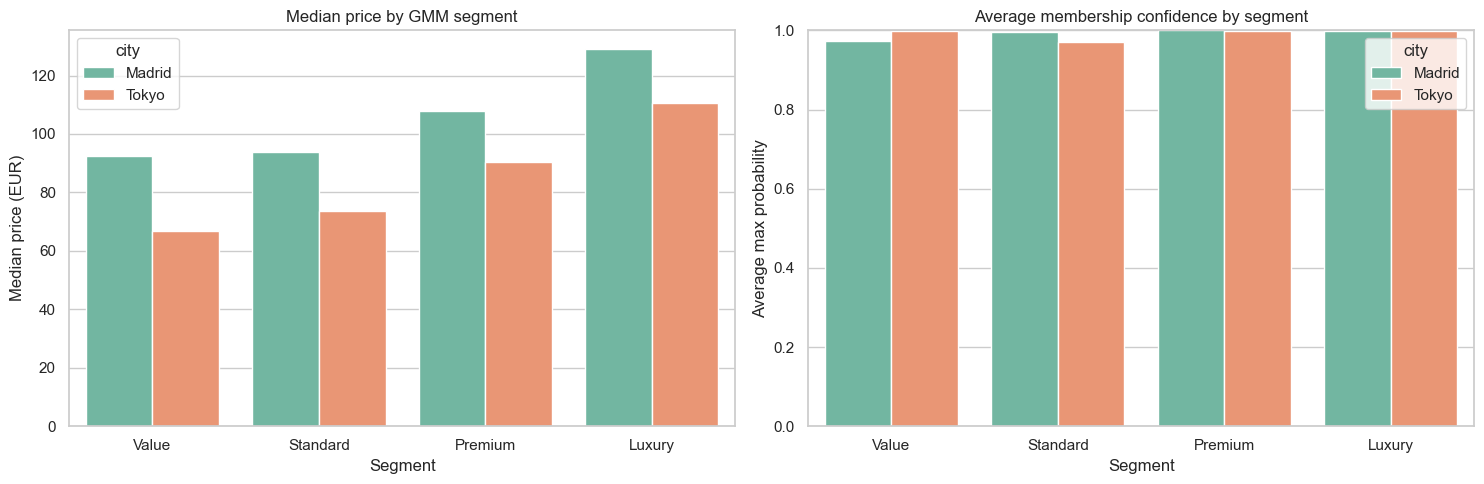

In [13]:
def plot_segment_profiles(profiles: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.barplot(data=profiles, x="segment", y="median_price_eur", hue="city", ax=axes[0])
    axes[0].set_title("Median price by GMM segment")
    axes[0].set_xlabel("Segment")
    axes[0].set_ylabel("Median price (EUR)")

    sns.barplot(data=profiles, x="segment", y="avg_membership_probability", hue="city", ax=axes[1])
    axes[1].set_title("Average membership confidence by segment")
    axes[1].set_xlabel("Segment")
    axes[1].set_ylabel("Average max probability")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


plot_segment_profiles(profiles_df)

The first plot checks whether the segment labels follow a clear price ladder. The second plot shows how confidently the GMM assigns listings to each segment.

---
## 9. Inspect Membership Confidence

In [14]:
def summarize_membership_confidence(segments: pd.DataFrame) -> pd.DataFrame:
    summary = (
        segments
        .groupby(["city", "segment"])
        .agg(
            listings=("membership_probability", "size"),
            avg_probability=("membership_probability", "mean"),
            median_probability=("membership_probability", "median"),
            low_confidence_share=("low_confidence_assignment", "mean"),
        )
        .reset_index()
    )
    return summary.round(3)


confidence_summary = summarize_membership_confidence(segments_df)
display(confidence_summary.style.format({
    "avg_probability": "{:.3f}",
    "median_probability": "{:.3f}",
    "low_confidence_share": "{:.2%}",
}))

,city,segment,listings,avg_probability,median_probability,low_confidence_share
0,Madrid,Luxury,4422,0.998,1.000,0.10%
1,Madrid,Premium,4305,1.000,1.000,0.00%
2,Madrid,Standard,5511,0.996,1.000,0.10%
3,Madrid,Value,208,0.974,1.000,1.90%
4,Tokyo,Luxury,8348,0.999,1.000,0.00%
5,Tokyo,Premium,8956,0.999,1.000,0.10%
6,Tokyo,Standard,602,0.970,1.000,2.70%
7,Tokyo,Value,1252,0.998,1.000,0.00%


This is one of the advantages of Gaussian Mixture Models. Instead of only returning a hard label, GMM shows whether a listing strongly belongs to one group or sits between groups.

---
## 10. PCA Visualisation

In [15]:
def make_pca_sample(
    labelled: pd.DataFrame,
    X_scaled: np.ndarray,
    city: str,
    sample_size: int = 2500,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    pca = PCA(n_components=2, random_state=random_state)
    coords = pca.fit_transform(X_scaled)
    coords_df = pd.DataFrame(coords, index=labelled.index, columns=["pc1", "pc2"])

    sample = labelled.sample(min(sample_size, len(labelled)), random_state=random_state).copy()
    sample = sample.join(coords_df.loc[sample.index])
    sample["city"] = city
    sample["pca_explained_variance_pc1"] = pca.explained_variance_ratio_[0]
    sample["pca_explained_variance_pc2"] = pca.explained_variance_ratio_[1]
    return sample[["city", "segment", "pc1", "pc2", "price_eur", "membership_probability", "pca_explained_variance_pc1", "pca_explained_variance_pc2"]]


pca_samples = []
for city in segmented_frames:
    labelled = segments_df[segments_df["city"] == city].copy()
    labelled.index = working_frames[city].index
    pca_samples.append(make_pca_sample(labelled, scaled_data[city], city))

pca_sample_df = pd.concat(pca_samples, ignore_index=True)

explained = (
    pca_sample_df
    .groupby("city")[["pca_explained_variance_pc1", "pca_explained_variance_pc2"]]
    .first()
    .reset_index()
)
display(explained.round(3))

,city,pca_explained_variance_pc1,pca_explained_variance_pc2
0,Madrid,0.238,0.170
1,Tokyo,0.265,0.144


PCA is only used for visualisation. The GMM itself is fitted on all nine scaled features, not just these two principal components.

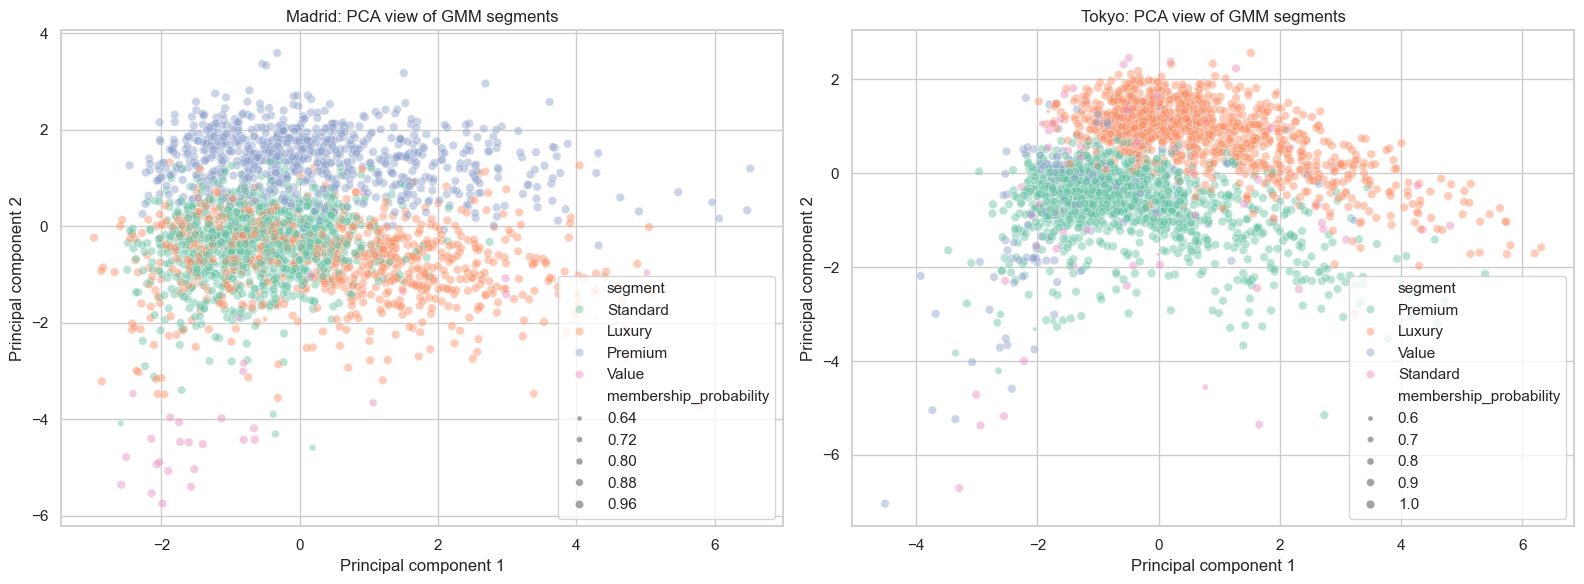

In [16]:
def plot_pca_segments(pca_sample: pd.DataFrame) -> None:
    cities = sorted(pca_sample["city"].unique())
    fig, axes = plt.subplots(1, len(cities), figsize=(8 * len(cities), 6))
    if len(cities) == 1:
        axes = [axes]

    for ax, city in zip(axes, cities):
        city_sample = pca_sample[pca_sample["city"] == city]
        sns.scatterplot(
            data=city_sample,
            x="pc1",
            y="pc2",
            hue="segment",
            size="membership_probability",
            sizes=(8, 38),
            alpha=0.45,
            ax=ax,
        )
        ax.set_title(f"{city}: PCA view of GMM segments")
        ax.set_xlabel("Principal component 1")
        ax.set_ylabel("Principal component 2")

    plt.tight_layout()
    plt.show()


plot_pca_segments(pca_sample_df)

The scatterplot projects the GMM segments into two dimensions. Larger dots have higher membership probability, so they are listings that the model assigns more confidently.

---
## 11. Save Outputs

In [17]:
scores_out = CLUSTER_OUTPUT_DIR / "gmm_scores.csv"
profiles_out = CLUSTER_OUTPUT_DIR / "gmm_cluster_profiles.csv"
segments_out = CLUSTER_OUTPUT_DIR / "gmm_listing_segments.csv"

scores_df.to_csv(scores_out, index=False)
profiles_df.to_csv(profiles_out, index=False)
segments_df.to_csv(segments_out, index=False)

print("Saved GMM scores to:", scores_out)
print("Saved GMM cluster profiles to:", profiles_out)
print("Saved GMM listing segment assignments to:", segments_out)

Saved GMM scores to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\gmm_scores.csv
Saved GMM cluster profiles to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\gmm_cluster_profiles.csv
Saved GMM listing segment assignments to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\gmm_listing_segments.csv


These files save the GMM diagnostics, segment profiles and listing-level segment assignments. They sit beside the K-means outputs so the algorithms can be compared later.

---
## 12. Key Metrics and Interpretation

In [18]:
gmm_k4_summary = scores_df[scores_df["n_components"] == N_COMPONENTS].copy()
gmm_k4_summary = gmm_k4_summary[[
    "city", "n_components", "aic", "bic", "silhouette_score",
    "avg_max_membership_probability", "low_confidence_share", "rows_used", "covariance_type",
]]

display(gmm_k4_summary.style.format({
    "aic": "{:.2f}",
    "bic": "{:.2f}",
    "silhouette_score": "{:.4f}",
    "avg_max_membership_probability": "{:.3f}",
    "low_confidence_share": "{:.2%}",
}))

,city,n_components,aic,bic,silhouette_score,avg_max_membership_probability,low_confidence_share,rows_used,covariance_type
2,Madrid,4,55726.36,57385.98,0.1210,0.997,0.08%,14446,full
9,Tokyo,4,109102.02,110823.47,0.1968,0.998,0.13%,19158,full


For Gaussian Mixture Models, the key metrics are:

- **AIC:** lower is better. It rewards model fit but penalises extra complexity.
- **BIC:** lower is better. It penalises complexity more heavily than AIC, so it is often preferred for choosing the number of components.
- **Silhouette score:** higher is better. It is calculated after assigning each row to its most likely component.
- **Average max membership probability:** higher means listings are assigned more confidently.
- **Low confidence share:** lower means fewer listings sit ambiguously between components.
- **Covariance type:** this notebook uses `full`, meaning each Gaussian component can have its own shape and orientation.

The four segment labels are still defined by sorting components by median price: Value, Standard, Premium and Luxury. Because GMM is probabilistic, it can be more flexible than K-means when clusters overlap.